# BEE 4750 Homework 3: Dissolved Oxygen and Monte Carlo

**Name**: Xindi Liu

**ID**: xl748

> **Due Date**
>
> Thursday, 10/16/25, 9:00pm

## Overview

### Instructions

-   Problem 1 asks you to implement a model for dissolved oxygen in a
    river with multiple waste releases and use this to develop a
    strategy to ensure regulatory compliance.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/Desktop/Cornell_Courses/FA_25/BEE_4750/hw3-xlcindy`


In [2]:
using Random
using Plots
using LaTeXStrings
using Distributions

## Problems (Total: 30 Points)

### Problem 1 (30 points)

A river which flows at 6 km/d is receiving waste discharges from two
sources which are 15 km apart. The oxygen reaeration rate is 0.55
day<sup>-1</sup>, and the decay rates of CBOD and NBOD are are 0.35 and
0.25 day<sup>-1</sup>, respectively. The river’s saturated dissolved
oxygen concentration is 10m g/L.

If the characteristics of the river inflow and waste discharges are
given in <a href="#tbl-river" class="quarto-xref">Table 1</a>, write a
Julia model to compute the dissolved oxygen concentration from the first
wastewater discharge to an arbitrary distance `d` km downstream. Use
your model to compute the minimum dissolved oxygen concentration up to
50 km downstream and how far downriver this maximum occurs.

| Parameter | River Inflow | Waste Stream 1 | Waste Stream 2 |
|:--:|---:|---:|---:|
| Inflow | 100,000 m<sup>3</sup>/d | 10,000 m<sup>3</sup>/d | 15,000 m<sup>3</sup>/d |
| DO Concentration | 7.5 mg/L | 5 mg/L | 5 mg/L |
| CBOD | 5 mg/L | 50 mg/L | 45 mg/L |
| NBOD | 5 mg/L | 35 mg/L | 35 mg/L |

Table 1: River inflow and waste stream characteristics for Problem 1.

### Problem 1.1

Implement the Streeter-Phelps (analytic) solution for the dissolved
oxygen concentration. Plot the dissolved oxygen concentration from the
first waste stream to 50 km downriver. What is the minimum value in
mg/L?

Minimum DO = 3.756 mg/L at x = 22.37 km


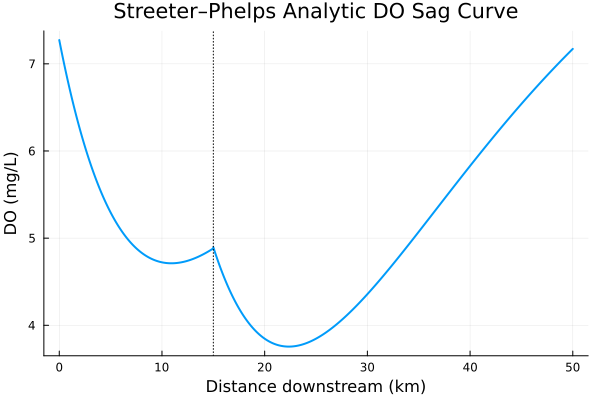

In [3]:
# Given parameters
U = 6          # flow speed km/d
ka = 0.55      # reaeration rate /d
kc = 0.35      # CBOD decay /d
kn = 0.25      # NBOD decay /d
Cs = 10        # saturation DO mg/L
x_dis2 = 15    # km to second discharge

# Flow and concentrations
Qr, Q1, Q2 = 100000, 10000, 15000   # m^3/d
DO_r, DO1, DO2 = 7.5, 5, 5
CBOD_r, CBOD1, CBOD2 = 5, 50, 45
NBOD_r, NBOD1, NBOD2 = 5, 35, 35

# Mixing function
mix(Qr, Qw, Cr, Cw) = (Qr*Cr + Qw*Cw) / (Qr + Qw)

# Analytic Streeter–Phelps solution for Dissolved Oxygen
function DO_analytic(C0, B0, N0, x, U, ka, kc, kn, Cs)
    a1 = exp.(-ka .* x ./ U)
    a2 = (kc ./ (ka .- kc)) .* (exp.(-kc .* x ./ U) .- exp.(-ka .* x ./ U))
    a3 = (kn ./ (ka .- kn)) .* (exp.(-kn .* x ./ U) .- exp.(-ka .* x ./ U))

    Cx = Cs .* (1 .- a1) .+ C0 .* a1 .- B0 .* a2 .- N0 .* a3
    return Cx
end

# Section 1: after first discharge
Qmix1 = Qr + Q1
Cmix1 = mix(Qr, Q1, DO_r, DO1)
Bmix1 = mix(Qr, Q1, CBOD_r, CBOD1)
Nmix1 = mix(Qr, Q1, NBOD_r, NBOD1)

x1 = range(0, x_dis2, length = 400)
C1 = DO_analytic(Cmix1, Bmix1, Nmix1, x1, U, ka, kc, kn, Cs)

# At 15 km (just before 2nd discharge)
C15 = C1[end] 
B15 = Bmix1 * exp(-kc * x_dis2 / U)  # CBOD remaining
N15 = Nmix1 * exp(-kn * x_dis2 / U)  # NBOD remaining

# Mix with second discharge
Qmix2 = Qmix1 + Q2
Cmix2 = mix(Qmix1, Q2, C15, DO2)   
Bmix2 = mix(Qmix1, Q2, B15, CBOD2)
Nmix2 = mix(Qmix1, Q2, N15, NBOD2)

# Section 2: from 15 to 50 km
x2_local = range(0, 50 - x_dis2, length = 400)
C2 = DO_analytic(Cmix2, Bmix2, Nmix2, x2_local, U, ka, kc, kn, Cs)

# Combine both sections
x_total = vcat(x1, x2_local .+ x_dis2)
C_total = vcat(C1, C2)

# Report minimum DO
minC = minimum(C_total)
x_min = x_total[argmin(C_total)]
println("Minimum DO = $(round(minC, digits = 3)) mg/L at x = $(round(x_min, digits = 2)) km")

# Plot DO Sag Curve
plot(x_total, C_total, lw = 2, xlabel = "Distance downstream (km)", ylabel = "DO (mg/L)",
     title = "Streeter–Phelps Analytic DO Sag Curve", legend = false)
vline!([x_dis2], label = "Second discharge", lw = 1, ls = :dot, color = :black)

Using the Streeter-Phelps analytic solution, the minimum DO value obtained is 3.76 mg/L at 22.37 km downstream, which is after mixing with the second discharge. This is likely due to the effect that before DO had enough time to fully reaerate, the addition of the new discharge led to the consumption of more oxygen again, which resulted in another sag right after the first one that hasn't yet fully recovered.

### Problem 1.2

Implement a numerically-integrated (discretized) solution for the
dissolved oxygen concentration. Using a resolution of 0.5km, conduct a
simulation and plot the results on the same axis as the plot from
Problem 1.1. How has the minimum value changed? What do you attribute
this difference to (be specific about the source of the difference(s) in
terms of the simulation dynamics, not just that one is a numerical
approximation).

Minimum DO = 3.694 mg/L at x = 22.0 km


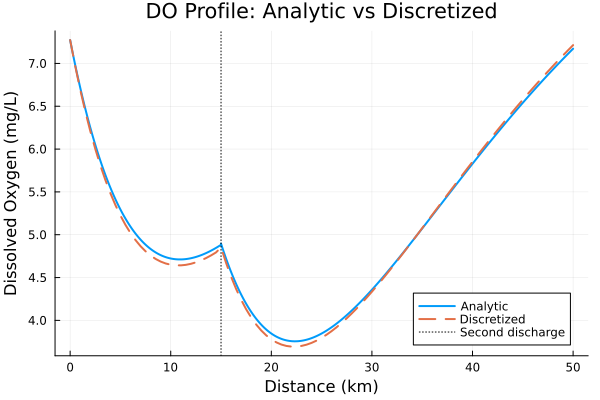

In [4]:
# Initial mixing after first discharge
Qmix1 = Qr + Q1
C = mix(Qr, Q1, DO_r, DO1)
B = mix(Qr, Q1, CBOD_r, CBOD1)
N = mix(Qr, Q1, NBOD_r, NBOD1)

# Discretization setup
dx = 0.5
x = 0:dx:50
Cvals, Bvals, Nvals = [C], [B], [N]

for xi in x[2:end]
    # ODE step (Forward Euler)
    dC = (ka*(Cs - C) - kc*B - kn*N) * dx / U
    dB = -kc * B * dx / U
    dN = -kn * N * dx / U

    C += dC
    B += dB
    N += dN

    # Mix at 15 km
    if abs(xi - x_dis2) < 1e-6
        Qmix2 = Qmix1 + Q2
        C = mix(Qmix1, Q2, C, DO2)
        B = mix(Qmix1, Q2, B, CBOD2)
        N = mix(Qmix1, Q2, N, NBOD2)
    end

    push!(Cvals, C)
    push!(Bvals, B)
    push!(Nvals, N)
end

# Plot numerical solution
plot(x, Cvals, lw = 2, label = "Discretized (0.5 km)")
xlabel!("Distance (km)")
ylabel!("DO (mg/L)")
title!("Numerical (Discretized) DO Profile")

# Report minimum DO
minC = minimum(Cvals)
x_min = x[argmin(Cvals)]
println("Minimum DO = $(round(minC, digits = 3)) mg/L at x = $(round(x_min, digits = 2)) km")

# Combined Plot
plot(x_total, C_total, lw = 2, label = "Analytic", xlabel = "Distance (km)",
     ylabel = "Dissolved Oxygen (mg/L)", title = "DO Profile: Analytic vs Discretized", legend = :bottomright)
plot!(x, Cvals, lw = 2, ls = :dash, label = "Discretized")
vline!([x_dis2], label = "Second discharge", lw = 1, ls = :dot, color = :black)

The minimum DO values for the two methods differ a bit by 0.062 mg/L, and the distance is 0.37km apart. There are multiple possible reasons behind this difference. In the Euler discretization, the time integral is approximated over each small step, but because B and N are decaying during the process, this is likely overestimating, yielding a slightly larger instantaneous OD per step. Cumulatively, this produces a slightly deeper DO sag and moves the minimum upstream a bit, as the deficit grows sooner with a larger demand. Another reason may be the mixed timing and how discontinuity is handled. Analytically, the pre-mix decays are computed exactly, then the mix is performed with the exact pre-mix values. With the Euler method however, the mix is computed after stepping into the 15 km position. This slight difference in time step produces the different post-mix initial conditions for the downstream reach. The last reason is likely how the different approaches treated the coupling aspect, as in one treated them locally and sequantially, while the other treated them combined. In summary, the reasons for the difference could be attributed to the difference between the two methods. 

### Problem 1.3

Using the analytic model, what is the minimum level of treatment (%
removal of organic waste; assume this is equivalent to the same level of
reduction of the CBOD and NBOD) for waste stream 1 that will ensure that
the dissolved oxygen concentration is in compliance with the 4 mg/L
standard along with a 5% margin of safety, assuming that waste stream 2
remains untreated? How about if only waste stream 2 is treated?

If only stream 1 is treated: removal = 27.61% 
         → min DO = 4.2 mg/L at x = 22.72 km
If only stream 2 is treated: removal = 21.75%
         → min DO = 4.2 mg/L at x = 21.14 km


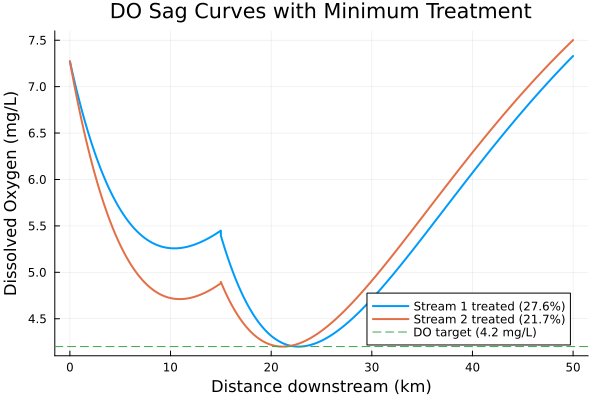

In [5]:
target_DO = 4.0 * 1.05   # 4 mg/L with 5% safety margin

# Function to compute minimum DO: same as 1.1
function compute_min_DO(CBOD1_mod, NBOD1_mod, CBOD2_mod, NBOD2_mod)
    # Section 1: after first discharge
    Qmix1 = Qr + Q1
    Cmix1 = mix(Qr, Q1, DO_r, DO1)
    Bmix1 = mix(Qr, Q1, CBOD_r, CBOD1_mod)
    Nmix1 = mix(Qr, Q1, NBOD_r, NBOD1_mod)

    x1 = range(0, x_dis2, length = 400)
    C1 = DO_analytic(Cmix1, Bmix1, Nmix1, x1, U, ka, kc, kn, Cs)

    # At 15 km (just before 2nd discharge)
    C15 = C1[end]
    B15 = Bmix1 * exp(-kc * x_dis2 / U)
    N15 = Nmix1 * exp(-kn * x_dis2 / U)

    # Mix with second discharge
    Qmix2 = Qmix1 + Q2
    Cmix2 = mix(Qmix1, Q2, C15, DO2)
    Bmix2 = mix(Qmix1, Q2, B15, CBOD2_mod)
    Nmix2 = mix(Qmix1, Q2, N15, NBOD2_mod)

    # Section 2: from 15 to 50 km
    x2_local = range(0, 50 - x_dis2, length = 400)
    C2 = DO_analytic(Cmix2, Bmix2, Nmix2, x2_local, U, ka, kc, kn, Cs)

    # Combine both sections
    x_total = vcat(x1, x2_local .+ x_dis2)
    C_total = vcat(C1, C2)
    minC = minimum(C_total)
    x_min = x_total[argmin(C_total)]
    return minC, x_min, x_total, C_total
end

# Bisection search to find minimum % removal
function find_min_fraction(treat_stream::Int; tol = 1e-4, max_iter = 50)
    lo, hi = 0.0, 1.0
    best = nothing

    for _ in 1:max_iter
        mid = 0.5 * (lo + hi)
        if treat_stream == 1
            CB1 = CBOD1 * (1 - mid)
            NB1 = NBOD1 * (1 - mid)
            minC, x_min, x_total, C_total = compute_min_DO(CB1, NB1, CBOD2, NBOD2)
        elseif treat_stream == 2
            CB2 = CBOD2 * (1 - mid)
            NB2 = NBOD2 * (1 - mid)
            minC, x_min, x_total, C_total = compute_min_DO(CBOD1, NBOD1, CB2, NB2)
        else
            error("treat_stream must be 1 or 2")
        end

        if minC ≥ target_DO
            hi = mid
            best = (mid, minC, x_min, x_total, C_total)
        else
            lo = mid
        end

        if hi - lo < tol
            break
        end
    end

    return isnothing(best) ? (NaN, NaN, NaN, [], []) : best
end

# Run the two scenarios
frac1, minC1, x_min1, x_total1, C_total1 = find_min_fraction(1)
frac2, minC2, x_min2, x_total2, C_total2 = find_min_fraction(2)

println("If only stream 1 is treated: removal = $(round(frac1*100, digits = 2))% 
         → min DO = $(round(minC1, digits=3)) mg/L at x = $(round(x_min1, digits = 2)) km")
println("If only stream 2 is treated: removal = $(round(frac2*100, digits = 2))%
         → min DO = $(round(minC2, digits=3)) mg/L at x = $(round(x_min2, digits = 2)) km")

# Plot DO sag curves for both cases
plot(x_total1, C_total1, lw = 2, label = "Stream 1 treated ($(round(frac1*100, digits = 1))%)")
plot!(x_total2, C_total2, lw = 2, label = "Stream 2 treated ($(round(frac2*100, digits = 1))%)")
hline!([target_DO], ls = :dash, label = "DO target (4.2 mg/L)")
xlabel!("Distance downstream (km)")
ylabel!("Dissolved Oxygen (mg/L)")
title!("DO Sag Curves with Minimum Treatment")

From the results, it seems like stream 2 requires less treatment than stream 1 to achieve compliance. This is likely because its discharge occurs farther downstream, where the river has already reaerated a bit. Both cases satisfy the 4 mg/L + 5% safety margin standard, with 4.2 mg/L as the value. 

### Problem 1.4

Suppose you are responsible for designing a waste treatment plan for
discharges into the river, with a regulatory mandate to keep the
dissolved oxygen concentration above 4 mg/L. Discuss whether you’d opt
to treat waste stream 2 alone or both waste streams equally. What other
information might you need to make a conclusion, if any?

I would choose to treat both streams equally. First of all, in this case, each stream requries a lower percent removal. If treatment cost scales roughly with percent removel, then the operational burden and required plant capacity will be smaller when treatment is distributed. Secondly, from a regulatory perspective, it makes more sense to distribute reponsibility rather than imposing larger burdens on one discharger, when both can make some effort and be reasonable in the amount of treatment needed for each. 

The additional information needed to make a final decision includes cost data, capital and O&M cost including fixed and variable costs; mass-load perspective for kg/day removed under each strategy; uncertainty and sensitivity ranges for ka, kc, kn, flows, etc.; seasonal, or worst-case conditions, as well as regulatory constraints like permit limits, and lastly operational feasibility in land, utilities, timelines, etc. 

### Problem 1.5

Suppose that it is known that the DO concentrations at the river inflow
can vary according to a $\text{LogNormal}(2.0, 0.15)$ distribution.
Conduct a Monte Carlo simulation of the DO concentration in the river.
If you treat only waste stream 1 (based on your analysis from Problem
1.3), what is the expected probability and 95% confidence interval that
the river fails to comply with the regulatory standard of 4 mg/L? How
did you decide that your Monte Carlo sample size was sufficiently large?

Monte Carlo samples = 20000
Failures = 569 / 20000
Estimated failure probability = 2.84%
95% CI = (2.61%, 3.08%)


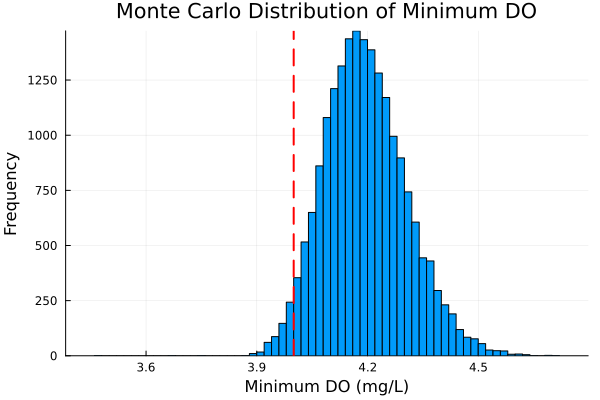

In [6]:
using Statistics

# Treatment for stream 1 only
removal1 = 0.2761    # 27.61% removal
CBOD1_treated = CBOD1 * (1 - removal1)
NBOD1_treated = NBOD1 * (1 - removal1)

function minimum_DO(DO_r, CBOD1, NBOD1, CBOD2, NBOD2)
    # section 1 (before second discharge)
    Qmix1 = Qr + Q1
    Cmix1 = mix(Qr, Q1, DO_r, DO1)
    Bmix1 = mix(Qr, Q1, CBOD_r, CBOD1)
    Nmix1 = mix(Qr, Q1, NBOD_r, NBOD1)
    x1 = range(0, x_dis2, length=400)
    C1 = DO_analytic(Cmix1, Bmix1, Nmix1, x1, U, ka, kc, kn, Cs)

    # at 15 km (before second discharge)
    C15 = C1[end]
    B15 = Bmix1 * exp(-kc * x_dis2 / U)
    N15 = Nmix1 * exp(-kn * x_dis2 / U)

    # mix with second discharge
    Qmix2 = Qmix1 + Q2
    Cmix2 = mix(Qmix1, Q2, C15, DO2)
    Bmix2 = mix(Qmix1, Q2, B15, CBOD2)
    Nmix2 = mix(Qmix1, Q2, N15, NBOD2)

    # section 2 (downstream of second discharge)
    x2_local = range(0, 50 - x_dis2, length=400)
    C2 = DO_analytic(Cmix2, Bmix2, Nmix2, x2_local, U, ka, kc, kn, Cs)

    minimum(vcat(C1, C2))
end

# Monte Carlo Simulation
Random.seed!(42)
n = 20000                         # sample size
dist = LogNormal(2.0, 0.15)       # LogNormal
DO_r_samples = rand(dist, n)

min_DO_vals = similar(DO_r_samples)
for i in 1:n
    min_DO_vals[i] = minimum_DO(DO_r_samples[i], CBOD1_treated, NBOD1_treated, CBOD2, NBOD2)
end

# Compute failure probability and 95% CI
failures = count(<(4.0), min_DO_vals)
p_hat = failures / n
se = sqrt(p_hat*(1 - p_hat) / n)
ci = (p_hat - 1.96*se, p_hat + 1.96*se)

println("Monte Carlo samples = $n")
println("Failures = $failures / $n")
println("Estimated failure probability = $(round(p_hat*100, digits = 2))%")
println("95% CI = ($(round(ci[1]*100, digits = 2))%, $(round(ci[2]*100, digits = 2))%)")

# Histogram plot of Monte Carlo simulations
using Plots
histogram(min_DO_vals, bins = 60, xlabel = "Minimum DO (mg/L)", ylabel = "Frequency", 
    title = "Monte Carlo Distribution of Minimum DO", legend = false)
vline!([4.0], color = :red, lw = 2, linestyle = :dash)

The expected failure probability is 2.84%, and the 95% confidence interval is (2.61%, 3.08%). To decide how much of the Monte Carlo sample size was sufficient, I first expected the failure probability to be small. Calculating the relative error, I obtaied a value for SE of around 0.0012, resulting in 8.3% for relative error. This is a pretty acceptable RE, since the estimate is ~3%. Further increasing the sample size to 50000 for example, may only change it by 0.01%, because we know SE decreases by $\frac{1}{\sqrt{n}}$

## References

List any external references consulted, including classmates.

1. Used ChatGPT for problems 1.1, 1.3, 1.5, mainly for helping understand how the coding language works and what questions are asking, not for discussions and analysis of problems. OpenAI. (2025). ChatGPT (Feb 1 GPT-4 model) [Large language model]. https://chat.openai.com

2. Used DeepSeek for problems 1.3, 1.5, for similar purposes. DeepSeek. (2025). DeepSeek Chat (Jun 25, 2024 version) [Large language model]. https://chat.deepseek.com